In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Case_Study_01/kredi_kart_musterileri.csv")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           9015 non-null   object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              9827 non-null   float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,9827.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.355782,2.346203,35.928409,3.812580,2.341167,2.455317,8618.263967,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.717283,1.298908,7.986416,1.554408,1.010622,1.106225,9127.293762,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,-23240.000000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2548.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4532.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11039.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,197.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [ ]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,1112
Months_on_book,0
Total_Relationship_Count,0


In [ ]:
#Eksik Veri Kontrolü
df = df.fillna(df.median(numeric_only=True))

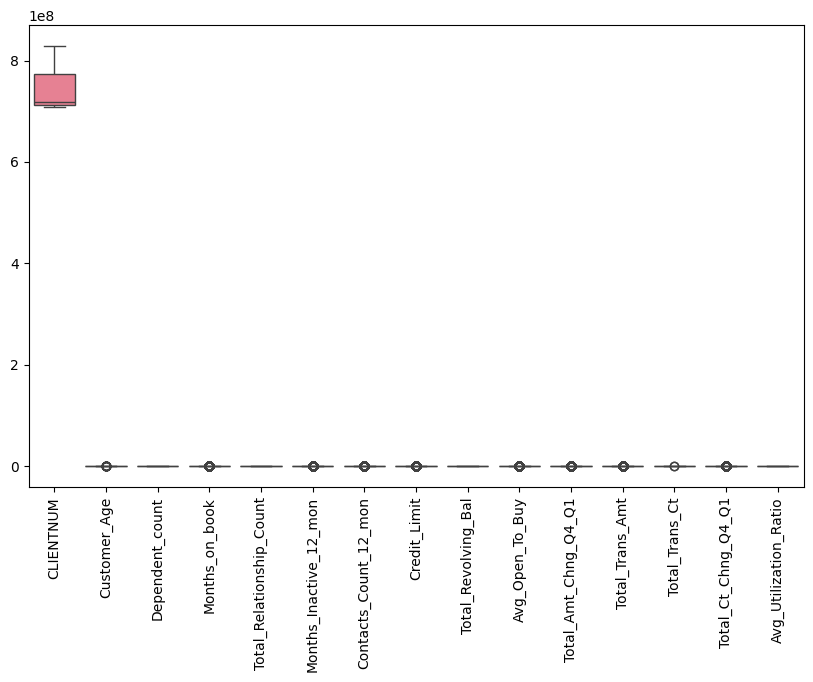

In [ ]:
#Aykırı Değer Kontrolü
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [ ]:
df["limit_kullanim_orani"] = df["Total_Trans_Amt"] / df["Credit_Limit"]
df["ortalama_harcama"] = df["Total_Trans_Amt"] / (df["Total_Trans_Ct"] + 1)

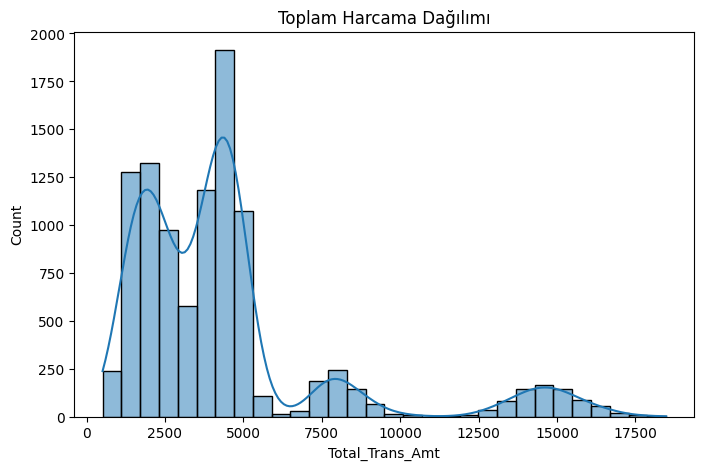

In [ ]:
#Keşifsel Veri Analizi
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Trans_Amt"], bins=30, kde=True)
plt.title("Toplam Harcama Dağılımı")
plt.show()

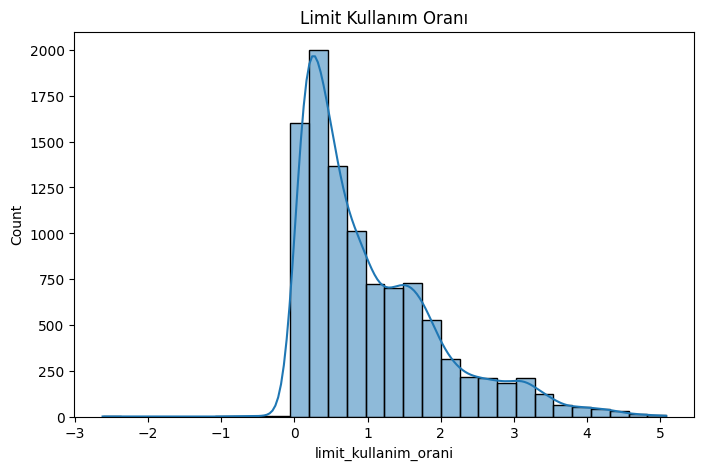

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["limit_kullanim_orani"], bins=30, kde=True)
plt.title("Limit Kullanım Oranı")
plt.show()

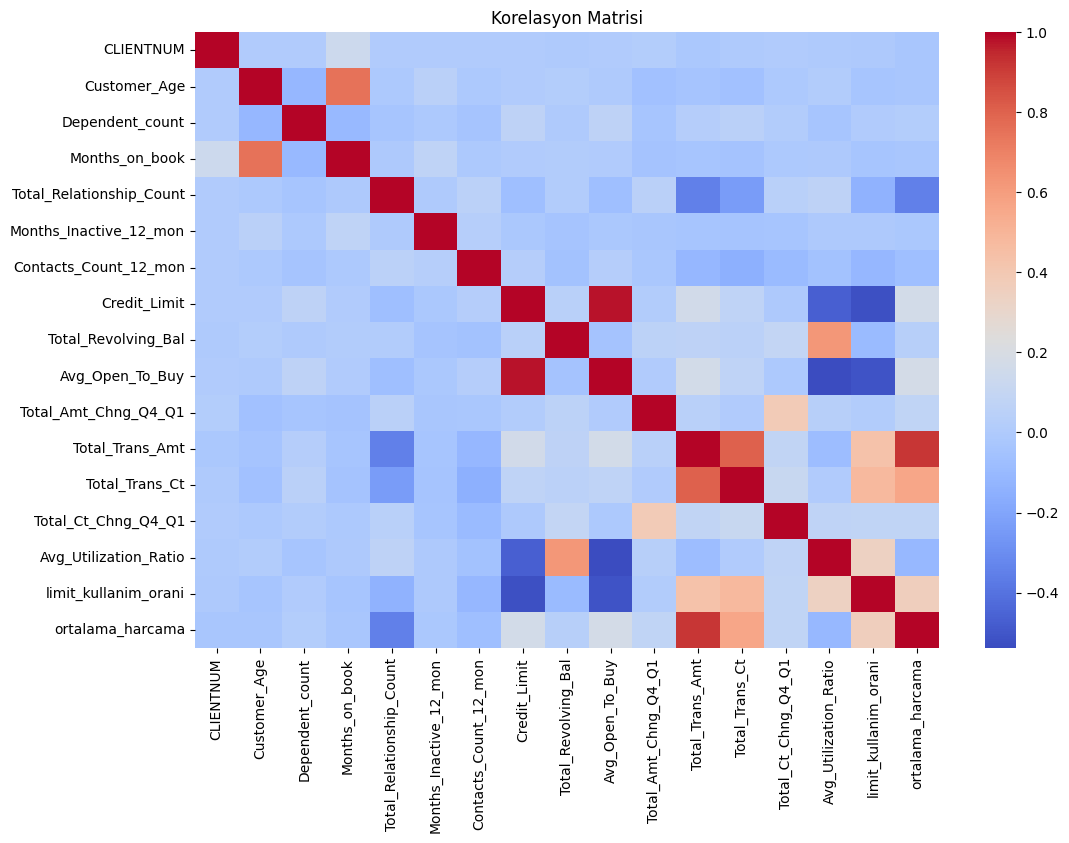

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()

In [ ]:
#K-Means
features = df.select_dtypes(include=np.number)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

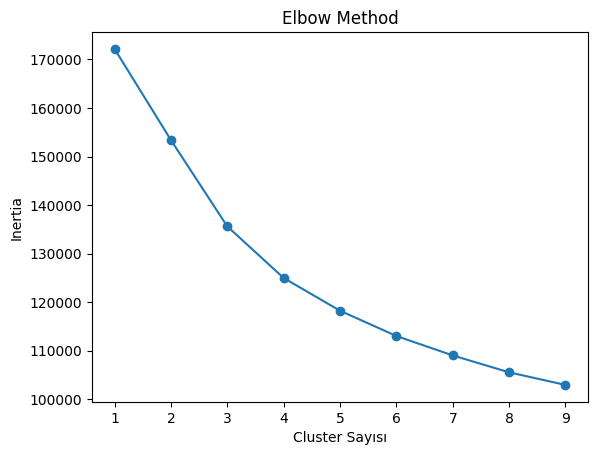

In [ ]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Cluster Sayısı")
plt.ylabel("Inertia")
plt.show()

In [ ]:
#Model eğitimi
kmeans = KMeans(n_clusters=4, random_state=42)
df["segment"] = kmeans.fit_predict(scaled_features)

df["segment"].value_counts()

,count
segment,
0,3958
2,3544
3,1461
1,1164


In [ ]:
df.groupby("segment").mean(numeric_only=True)

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,limit_kullanim_orani,ortalama_harcama
segment,,,,,,,,,,,,,,,,,
0,7.392204e+08,46.341334,2.317332,35.757959,4.079333,2.306973,2.334765,3542.557782,1682.647297,1848.257605,0.793077,3556.992420,63.594492,0.762046,0.558337,1.294737,54.210304
1,7.361608e+08,45.186426,2.362543,35.022337,2.221649,2.256014,2.236254,11939.699313,1302.000859,11161.116838,0.785980,12397.384880,100.650344,0.733853,0.177332,1.745728,121.647468
2,7.396305e+08,46.645316,2.284424,36.317720,3.980813,2.422968,2.630079,5866.323448,511.420993,5490.365547,0.710001,3065.316591,56.653781,0.646063,0.081897,0.889745,52.232861
3,7.403668e+08,46.624230,2.561259,36.167693,3.949350,2.303217,2.532512,25559.052704,1223.747433,24555.221081,0.770563,3578.075291,59.670773,0.720495,0.052903,0.150596,56.320364


In [ ]:
#Risk Analizi
# Convert 'Attrition_Flag' to numerical (0 or 1)
df['Attrition_Flag_Numeric'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

X = df.drop(['Attrition_Flag', 'Attrition_Flag_Numeric'], axis=1)
y = df['Attrition_Flag_Numeric']

# Encode categorical features in X
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[1679   20]
 [  61  266]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1699
           1       0.93      0.81      0.87       327

    accuracy                           0.96      2026
   macro avg       0.95      0.90      0.92      2026
weighted avg       0.96      0.96      0.96      2026

